# Sweep progress — per problem, per acquisition

One plot **per problem** (all 10 registered test problems). Each bar is an **acquisition** and its height
is the number of completed result cells for that (problem, acq), aggregated over supported models ×
replicate counts × seeds. The dashed **crimson line marks the target** (full completion); a bar turns
green when it reaches it. Bars are annotated `done/target`.

Problems are tagged **live** (equations implemented — currently the 4 one-D ones) or **pending** (the 6
multi-dim stubs, not yet runnable). Pending problems show all-zero bars — everything is wired up, they
just have no data until the framework is generalized to d dimensions and they are swept.

**Target per acq** = (# models that support the acq) × (# replicate counts) × (# seeds), auto-computed
(set `TARGET_PER_ACQ` to pin a fixed line). This only globs `results/` — re-run to refresh while live.
**Kernel: ml_gp_env.**

In [1]:
import os, re, sys, glob
sys.path.insert(0, os.path.abspath('.'))
import numpy as np, matplotlib.pyplot as plt
import run                                   # HERE, RESULTS, N_REP_LIST (imported constants only)
from utils import problems as P, acquisitions
from utils.models import MODELS

# ---- config ----
RESULTS = run.RESULTS
NREP    = run.N_REP_LIST                     # [3, 10]
SEEDS   = 5                                  # <-- current sweep: run.py --seeds 5
TARGET_PER_ACQ = None                        # None -> auto (models×nreps×seeds); or e.g. 90 for one fixed line
FUNCTIONS = list(P.PROBLEMS)                 # ALL 10 registered problems (4 live + 6 multi-dim stubs)
DEFINED   = set(P.defined_problems())        # which ones actually have equations wired in
CFG = acquisitions.CONFIG_ORDER

def status(fn):
    return 'live' if fn in DEFINED else 'pending'

def _models_for(acf):
    return [m for m in MODELS if acf in MODELS[m].supports and not MODELS[m].aux]

def completed(function, acf, param, nreps=None):
    # count ONLY seeds <= SEEDS (1-D problems carry 30 seeds on disk from the earlier sweep).
    # nreps=None counts all NREP; pass e.g. [10] to count just the 10-replicate cells.
    want = set(NREP if nreps is None else nreps)
    tag = acquisitions.acf_tag(acf, param); n = 0
    for m in _models_for(acf):
        base = os.path.join(RESULTS, function, m, tag)
        for f in (glob.glob(os.path.join(base, '**', '*.npz'), recursive=True)
                  + glob.glob(os.path.join(base, '**', '*.mat'), recursive=True)):
            mm = re.search(r'seed(\d+)\.(npz|mat)$', f)
            nr = re.search(r'nrep(\d+)', f)
            if mm and nr and int(mm.group(1)) <= SEEDS and int(nr.group(1)) in want:
                n += 1
    return n

def target(acf, nreps=None):
    nreps = NREP if nreps is None else nreps
    if TARGET_PER_ACQ:                       # scale a fixed override to the nrep subset
        return int(round(TARGET_PER_ACQ * len(nreps) / len(NREP)))
    return len(_models_for(acf)) * len(nreps) * SEEDS

print(f'results dir : {RESULTS}')
print(f'problems    : {len(FUNCTIONS)}  ({len(DEFINED)} live, {len(FUNCTIONS)-len(DEFINED)} pending)')
print(f'nreps={NREP}  seeds={SEEDS}   target/acq = models_supporting × {len(NREP)} × {SEEDS}'
      + (f'   (overridden to {TARGET_PER_ACQ})' if TARGET_PER_ACQ else ''))
for acf, p in CFG:
    print(f'  {acquisitions.label(acf, p):16s} target={target(acf):4d}  ({len(_models_for(acf))} models)')

results dir : /data/zhq7531/IDEAL/hetero_lvgp/benchmark/results
problems    : 10  (10 live, 0 pending)
nreps=[3, 10]  seeds=5   target/acq = models_supporting × 2 × 5
  LCB              target=  40  (4 models)
  PI               target=  40  (4 models)
  EI               target=  40  (4 models)
  HAEI(γ=0.5)      target=  30  (3 models)
  ANPEI(β=0.8)     target=  30  (3 models)
  RAHBO(α=0.5)     target=  30  (3 models)


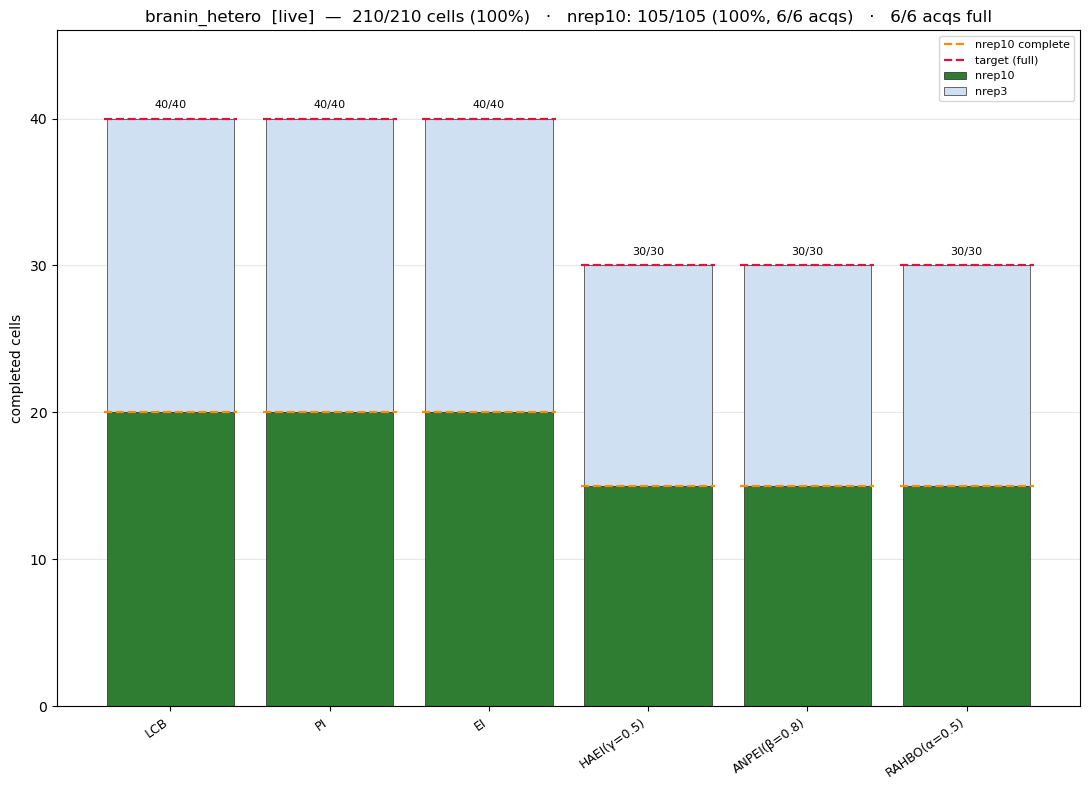

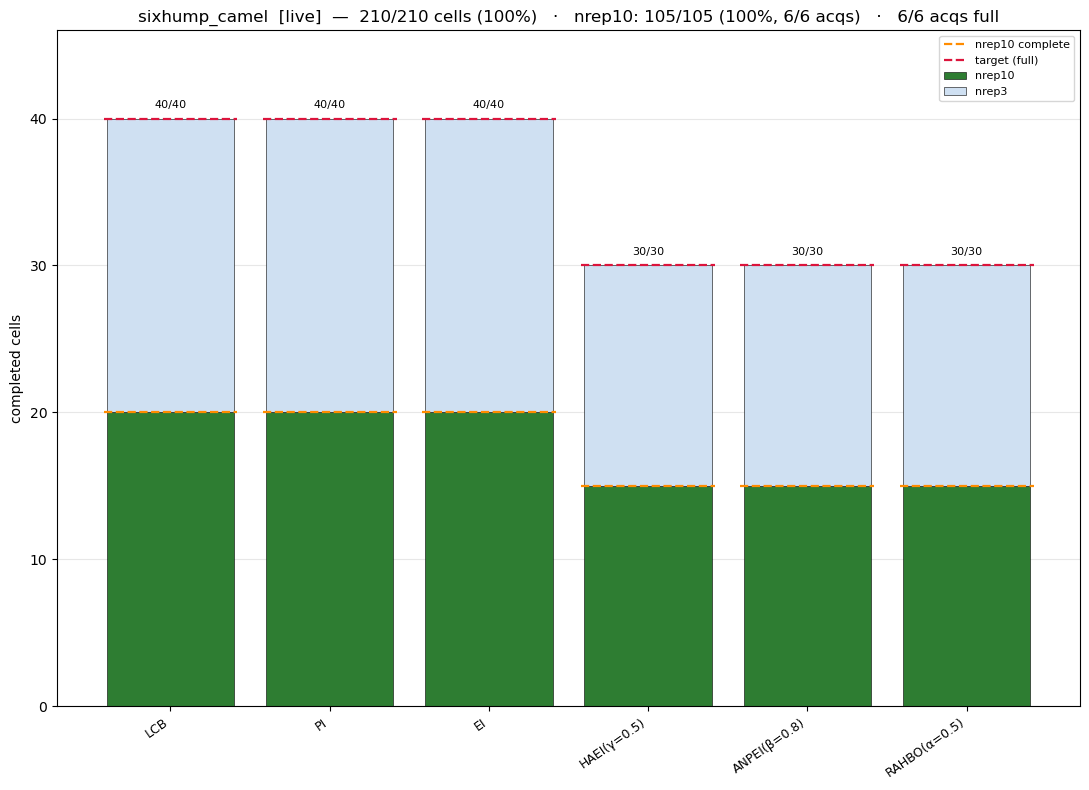

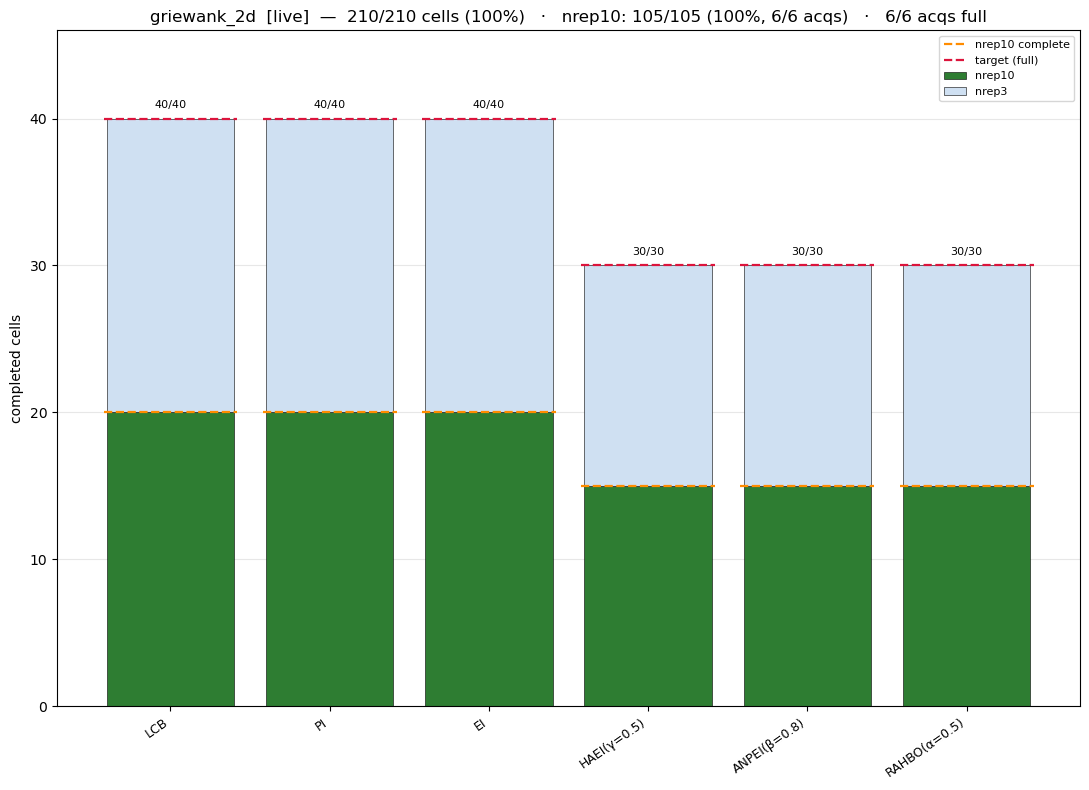

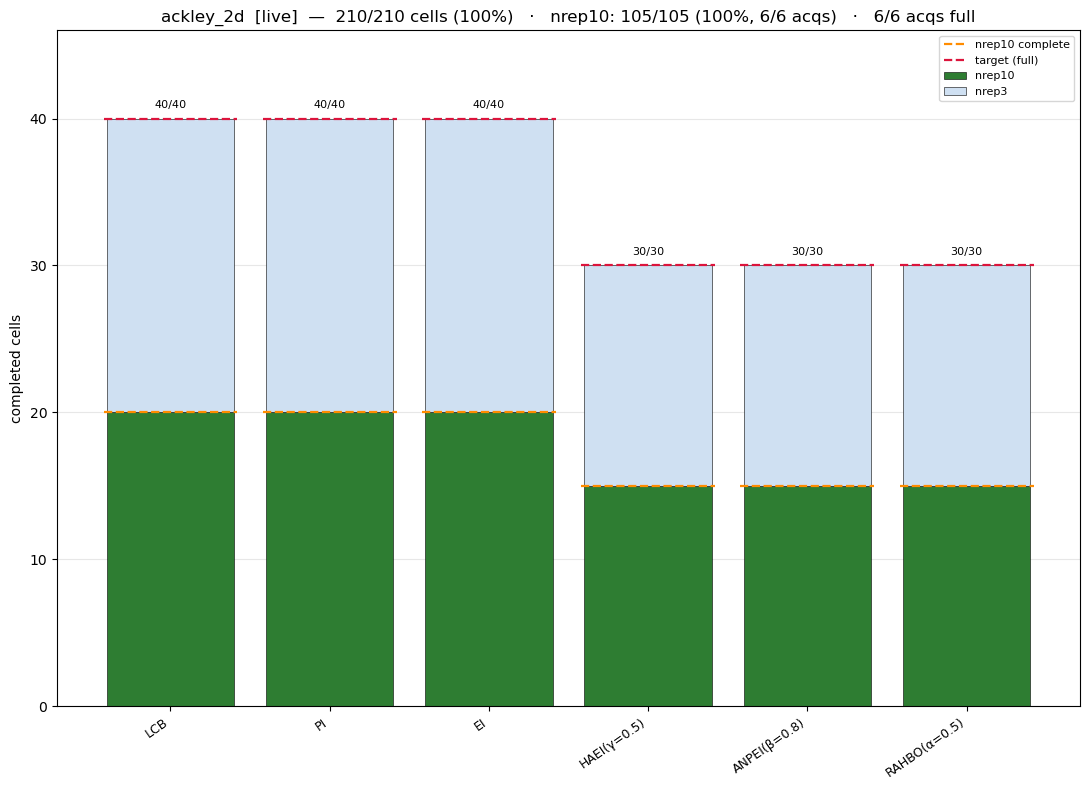

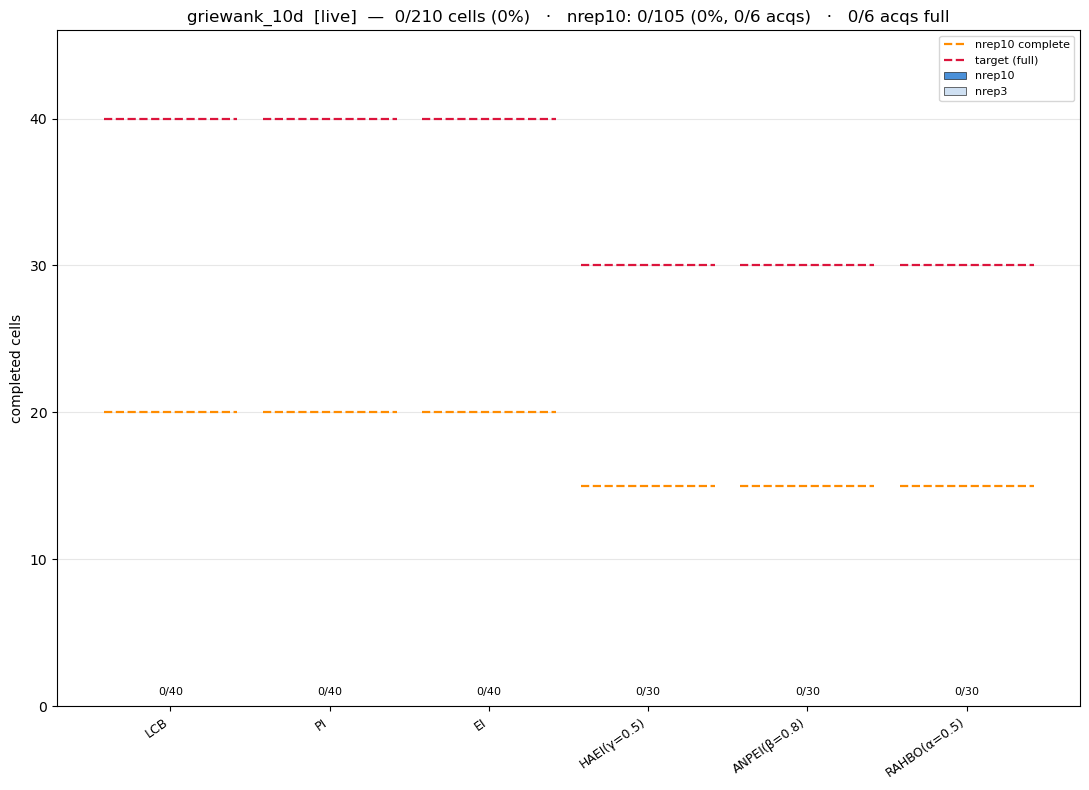

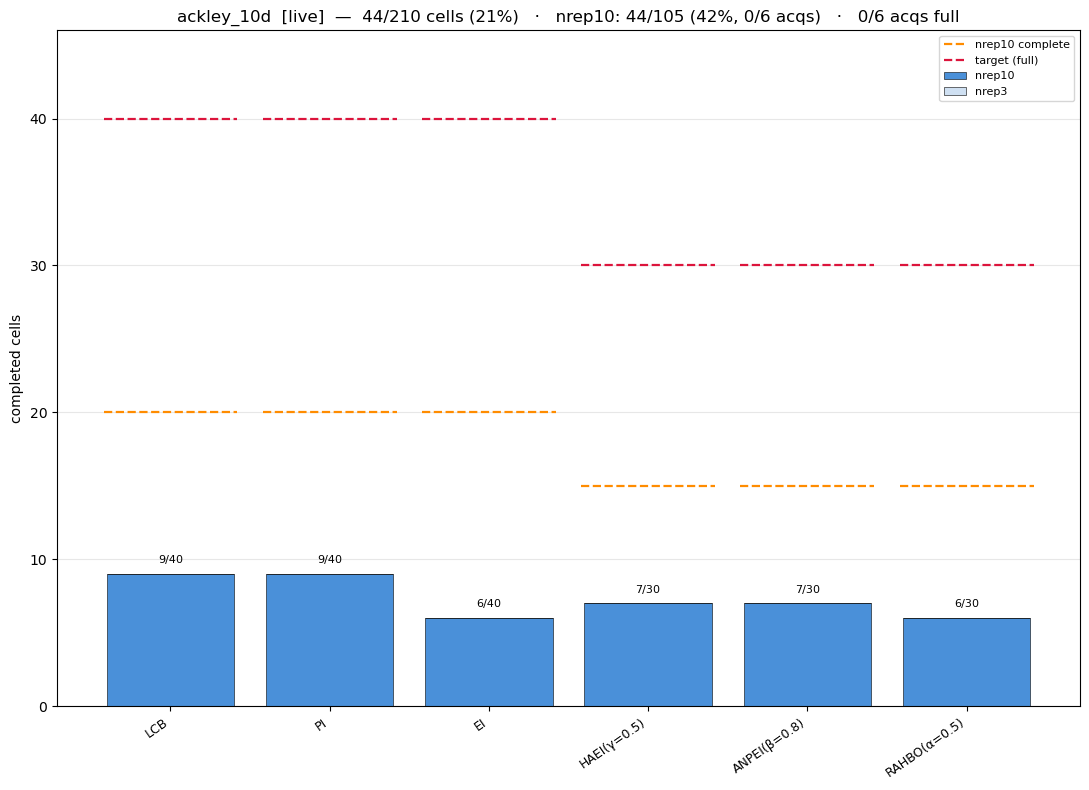

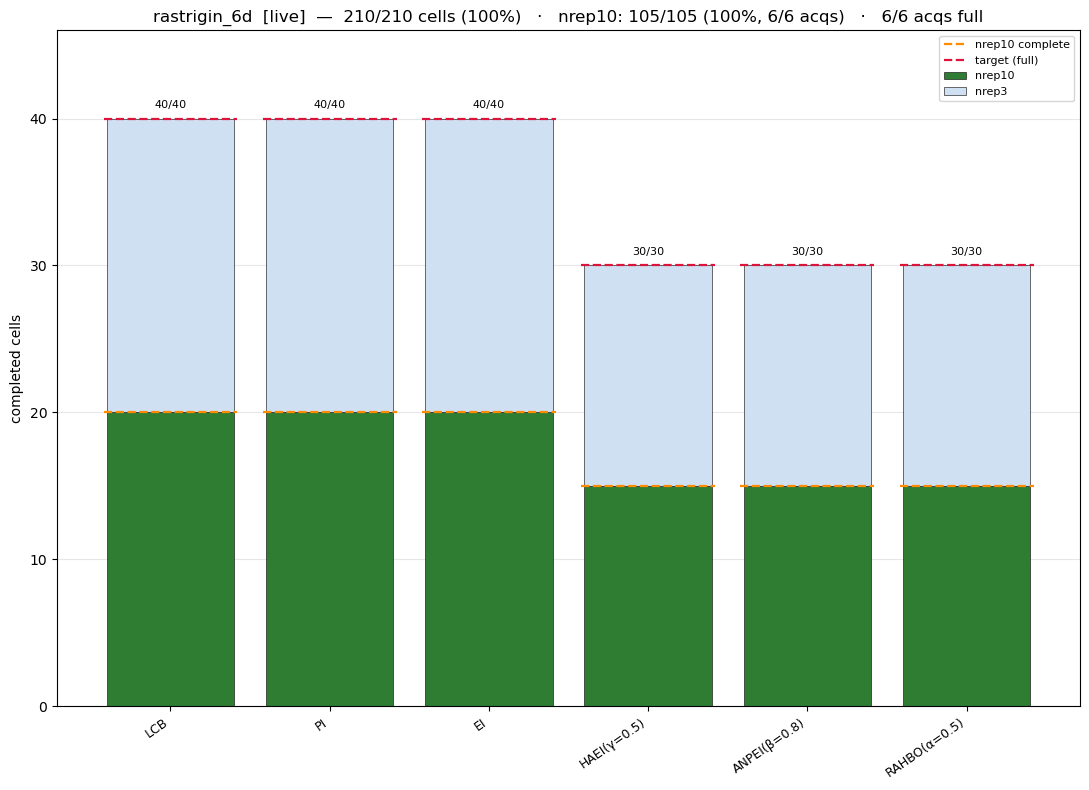

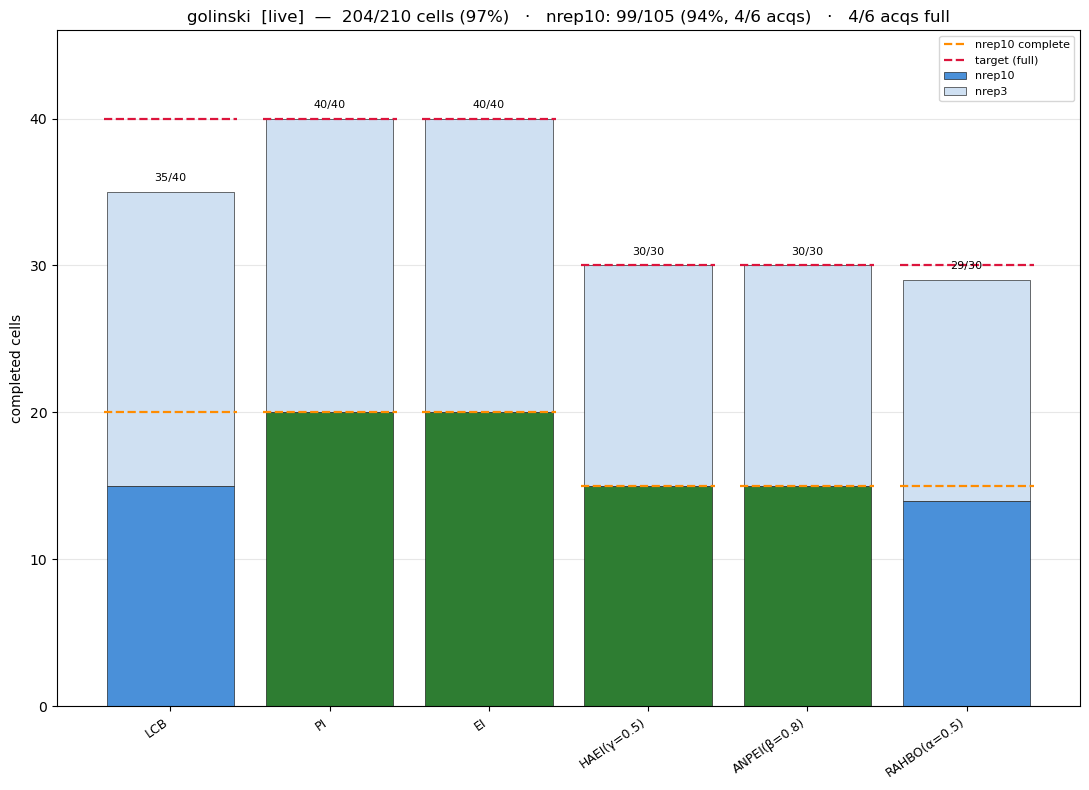

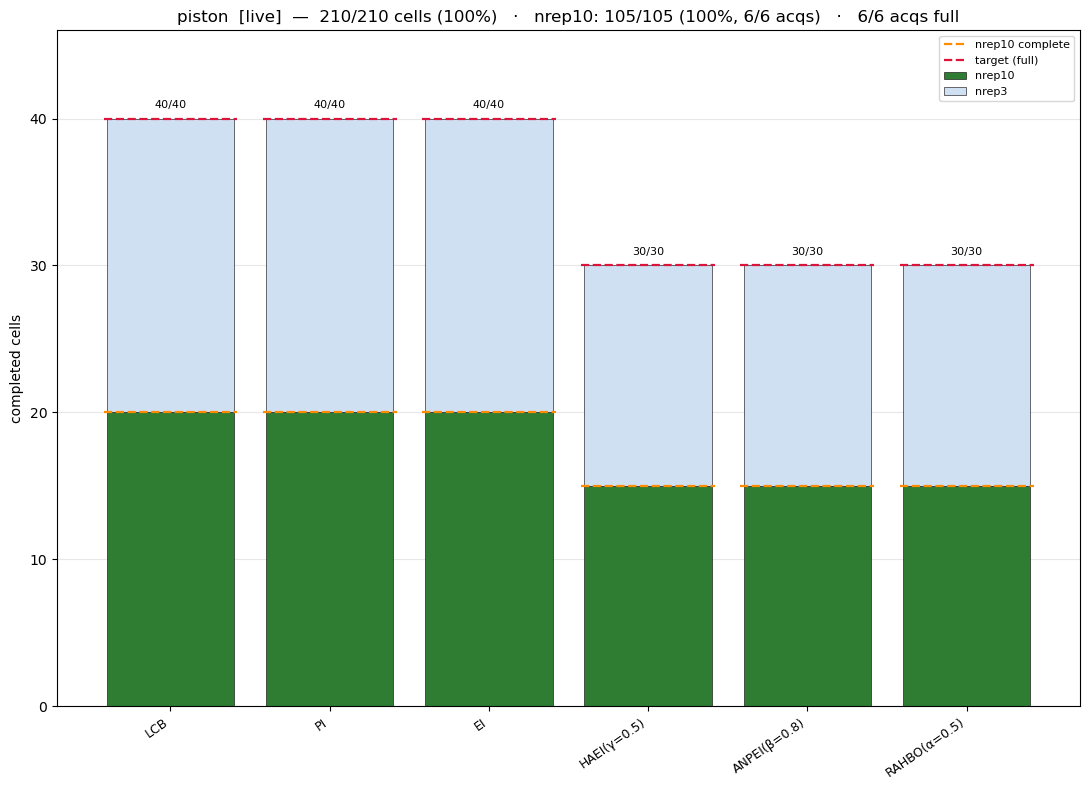

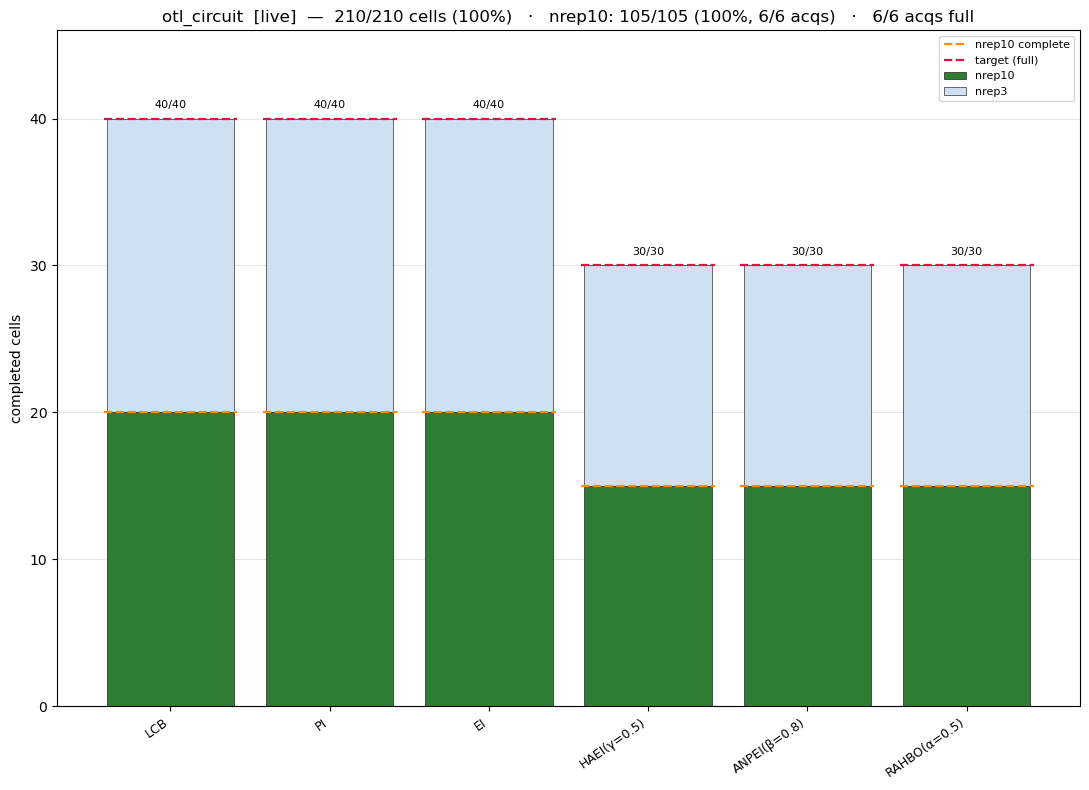

In [2]:
# ---- per-problem progress: bars stack nrep10 (bottom) + nrep3 (top);
#      orange line = nrep10 complete, crimson line = full (both nreps) complete ----
for function in FUNCTIONS:
    labels = [acquisitions.label(a, p) for a, p in CFG]
    n10 = np.array([completed(function, a, p, nreps=[10]) for a, p in CFG])
    n03 = np.array([completed(function, a, p, nreps=[3])  for a, p in CFG])
    counts = n10 + n03
    t10  = np.array([target(a, nreps=[10]) for a, _ in CFG])
    tful = np.array([target(a)             for a, _ in CFG])
    live = function in DEFINED
    fig, ax = plt.subplots(figsize=(11, 8))
    # nrep10 portion (green once its own line is reached, else blue); nrep3 stacked on top (lighter)
    c10 = ['#2e7d32' if a >= b else ('#4a90d9' if live else '#c9ced6') for a, b in zip(n10, t10)]
    ax.bar(range(len(counts)), n10, color=c10, edgecolor='k', lw=0.4, zorder=2, label='nrep10')
    ax.bar(range(len(counts)), n03, bottom=n10, color=('#cfe0f2' if live else '#e5e8ec'),
           edgecolor='k', lw=0.4, zorder=2, label='nrep3')
    for i in range(len(CFG)):
        ax.hlines(t10[i],  i-0.42, i+0.42, color='darkorange', ls='--', lw=1.6, zorder=3,
                  label='nrep10 complete' if i == 0 else None)
        ax.hlines(tful[i], i-0.42, i+0.42, color='crimson',    ls='--', lw=1.6, zorder=3,
                  label='target (full)' if i == 0 else None)
    for i, (c, t) in enumerate(zip(counts, tful)):
        ax.text(i, c + tful.max()*0.015, f'{int(c)}/{int(t)}', ha='center', va='bottom', fontsize=8)
    done, total = int(counts.sum()), int(tful.sum())
    d10, tt10   = int(n10.sum()), int(t10.sum())
    pct   = 100*done/total if total else 0
    pct10 = 100*d10/tt10   if tt10  else 0
    ndone   = int((counts >= tful).sum())
    n10done = int((n10 >= t10).sum())
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=9)
    ax.set_ylim(0, max(tful.max(), counts.max(), 1)*1.15); ax.set_ylabel('completed cells')
    ax.set_title(f'{function}  [{status(function)}]  —  {done}/{total} cells ({pct:.0f}%)'
                 f'   ·   nrep10: {d10}/{tt10} ({pct10:.0f}%, {n10done}/{len(CFG)} acqs)'
                 f'   ·   {ndone}/{len(CFG)} acqs full')
    ax.legend(loc='upper right', fontsize=8); ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()
    plt.show()


In [3]:
# ---- overall roll-up across all problems (with nrep10 completeness) ----
gd = gt = g10 = gt10 = 0
print(f'{"problem":16s} {"status":8s} {"done":>6s} {"total":>6s}  {"%":>4s}  {"nrep10%":>8s}')
for function in FUNCTIONS:
    d   = sum(completed(function, a, p)             for a, p in CFG)
    t   = sum(target(a)                             for a, _ in CFG)
    d10 = sum(completed(function, a, p, nreps=[10]) for a, p in CFG)
    t10 = sum(target(a, nreps=[10])                 for a, _ in CFG)
    gd += d; gt += t; g10 += d10; gt10 += t10
    print(f'{function:16s} {status(function):8s} {d:6d} {t:6d}  {100*d/t if t else 0:4.0f}'
          f'  {100*d10/t10 if t10 else 0:7.0f}')
print('-'*56)
print(f'{"ALL ("+str(len(FUNCTIONS))+" probs)":16s} {"":8s} {gd:6d} {gt:6d}'
      f'  {100*gd/gt if gt else 0:4.0f}  {100*g10/gt10 if gt10 else 0:7.0f}')
print(f'nrep10 overall: {g10}/{gt10} ({100*g10/gt10 if gt10 else 0:.0f}%)   '
      f'all-nrep overall: {gd}/{gt} ({100*gd/gt if gt else 0:.0f}%)')


problem          status     done  total     %   nrep10%
branin_hetero    live        210    210   100      100
sixhump_camel    live        210    210   100      100
griewank_2d      live        210    210   100      100
ackley_2d        live        210    210   100      100
griewank_10d     live          0    210     0        0
ackley_10d       live         44    210    21       42
rastrigin_6d     live        210    210   100      100
golinski         live        204    210    97       94
piston           live        210    210   100      100
otl_circuit      live        210    210   100      100
--------------------------------------------------------
ALL (10 probs)              1718   2100    82       84
nrep10 overall: 878/1050 (84%)   all-nrep overall: 1718/2100 (82%)
